In [1]:
import numpy as np
import pandas as pd

In [2]:
df=pd.read_csv('heart.csv')

In [4]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [69]:
X = df[['age', 'chol']]
y=df['target']

In [70]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [71]:
from sklearn.ensemble import StackingClassifier,GradientBoostingClassifier,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [72]:
lr=LogisticRegression()
kn=KNeighborsClassifier()
dt=DecisionTreeClassifier()
rfc=RandomForestClassifier()

In [73]:
estimators=[('lr',lr),('dt',dt),('kn',kn)]
for name,model in estimators:
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    print(name, accuracy_score(y_test,y_pred))

lr 0.5573770491803278
dt 0.5245901639344263
kn 0.6065573770491803


In [74]:
se=StackingClassifier(estimators=estimators,final_estimator=rfc,cv=10)

In [75]:
se.fit(x_train,y_train)

,estimators,"[('lr', ...), ('dt', ...), ...]"
,final_estimator,RandomForestClassifier()
,cv,10
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [32]:
y_pred1=se.predict(x_test)
accuracy_score(y_test,y_pred)

0.6885245901639344

[Text(0.5, 0.8333333333333334, 'x[0] <= 54.5\ngini = 0.495\nsamples = 242\nvalue = [109, 133]'),
 Text(0.25, 0.5, 'x[1] <= 272.5\ngini = 0.419\nsamples = 114\nvalue = [34, 80]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.375, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.75, 0.5, 'x[1] <= 337.5\ngini = 0.485\nsamples = 128\nvalue = [75, 53]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, '\n  (...)  \n'),
 Text(0.875, 0.16666666666666666, '\n  (...)  \n')]

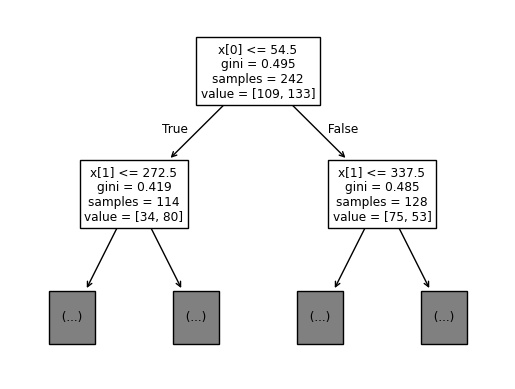

In [76]:
plot_tree(dt,max_depth=1)

In [77]:
import matplotlib.pyplot as plt

In [82]:
def plot_decision_boundary(clf):
    plt.figure(figsize=(12,8))
    x_range=np.linspace(X.min(),X.max(),200)
    xx1,xx2=np.meshgrid(x_range,x_range)
    y_hat=clf.predict(np.c_[xx1.ravel(),xx2.ravel()])
    y_hat=y_hat.reshape(xx1.shape)
    plt.contourf(xx1,xx2,y_hat,alpha=0.2)
    plt.scatter(X[:0],X[:1],c=y)
    plt.show()   

In [ ]:
plt.scatter(X[:0],X[:1],c=y)